In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#https://www.kaggle.com/datasets/uciml/iris/data

In [3]:
df = pd.read_csv("11-iris.csv")

In [4]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [6]:
df["Species"].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [7]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


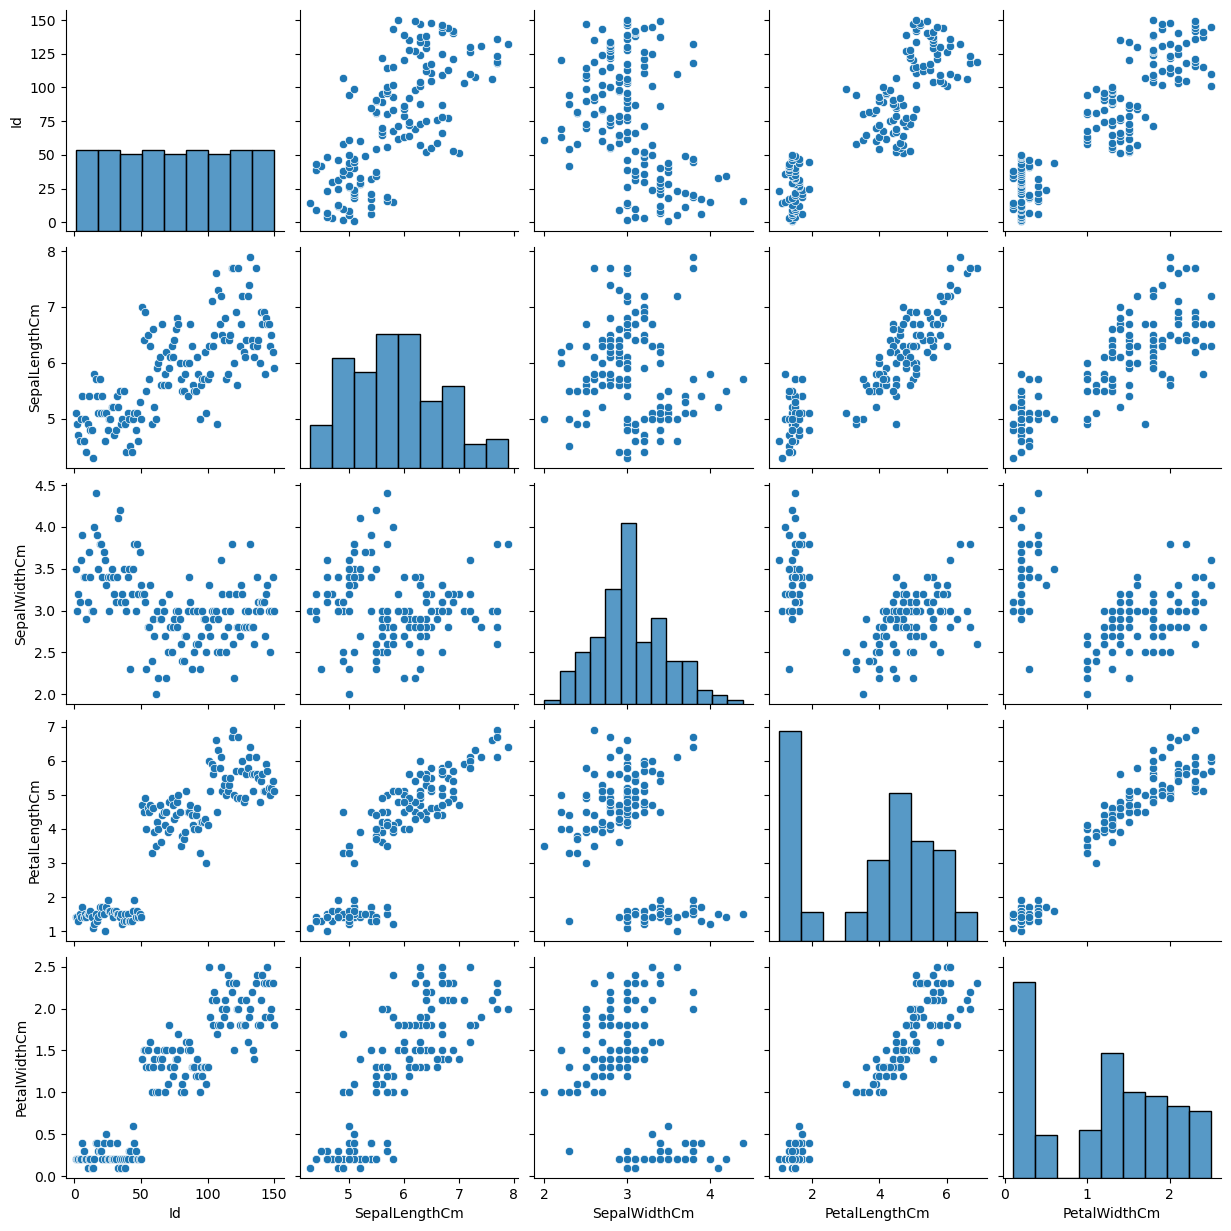

In [8]:
sns.pairplot(df)
plt.show()

In [9]:
df.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

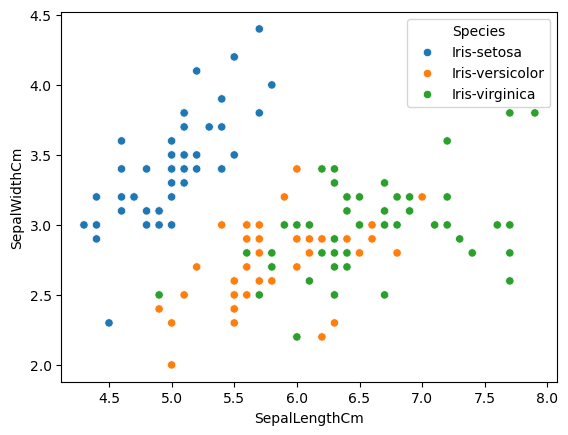

In [10]:
sns.scatterplot(x=df["SepalLengthCm"], y=df["SepalWidthCm"], hue=df["Species"])
plt.show()

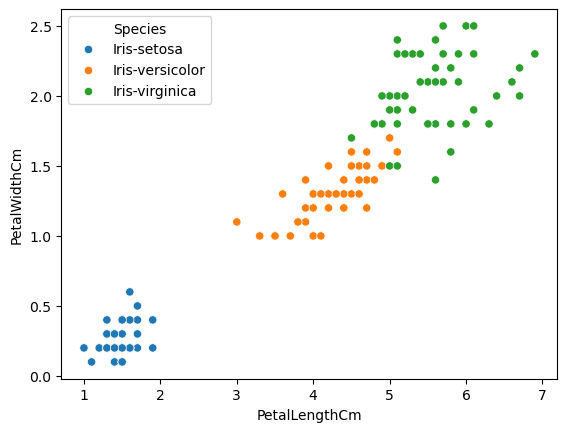

In [11]:
sns.scatterplot(x=df["PetalLengthCm"], y=df["PetalWidthCm"], hue=df["Species"])
plt.show()

In [12]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [13]:
df = df.drop("Id", axis=1)

In [14]:
from sklearn.preprocessing import LabelEncoder

In [15]:
label_encoder = LabelEncoder()
df["Species"] = label_encoder.fit_transform(df["Species"])

In [16]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [17]:
df.tail()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2
149,5.9,3.0,5.1,1.8,2


In [18]:
df["Species"].value_counts()

Species
0    50
1    50
2    50
Name: count, dtype: int64

In [19]:
X = df.drop("Species", axis=1)
y = df["Species"]

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=15)

In [22]:
from sklearn.preprocessing import StandardScaler

In [23]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
from sklearn.naive_bayes import GaussianNB

In [25]:
gnb = GaussianNB()

In [26]:
gnb.fit(X_train_scaled, y_train)
y_pred = gnb.predict(X_test_scaled)

In [27]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [28]:
print("confusion matrix: \n", confusion_matrix(y_pred, y_test))
print("accuracy score: ", accuracy_score(y_pred, y_test))
print("classification report: ", classification_report(y_pred, y_test))

confusion matrix: 
 [[12  0  0]
 [ 0 14  0]
 [ 0  0 12]]
accuracy score:  1.0
classification report:                precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



In [29]:
#svc logistic regression ile de dene gorsellestirme yap

<Axes: xlabel='SepalLengthCm', ylabel='SepalWidthCm'>

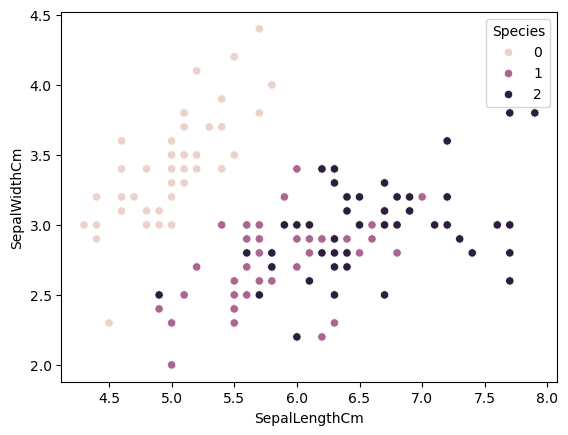

In [30]:
sns.scatterplot(
    data=df,
    x="SepalLengthCm",
    y="SepalWidthCm",
    hue="Species"
)

<Axes: xlabel='Species', ylabel='PetalLengthCm'>

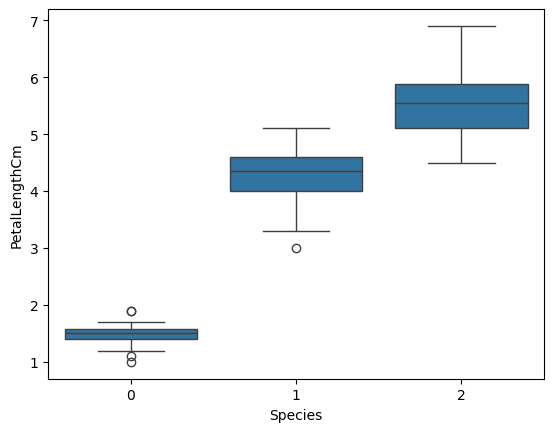

In [31]:
sns.boxplot(x="Species", y="PetalLengthCm", data=df)

C:\Users\furka\AppData\Local\Temp\ipykernel_18920\3542948724.py:2: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  ax = sns.stripplot(x="Species", y="PetalLengthCm", data=df, jitter=True, edgecolor="gray")


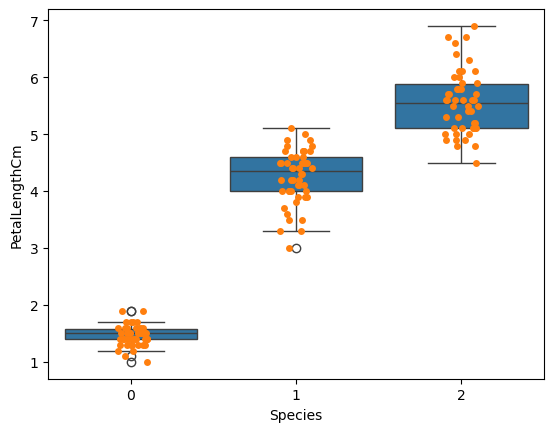

In [32]:
ax = sns.boxplot(x="Species", y="PetalLengthCm", data=df)
ax = sns.stripplot(x="Species", y="PetalLengthCm", data=df, jitter=True, edgecolor="gray")

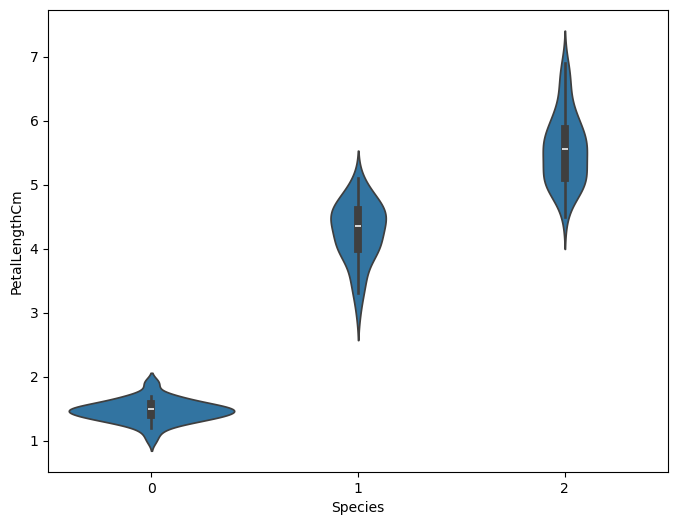

In [33]:
plt.figure(figsize=(8, 6))
sns.violinplot(x="Species", y="PetalLengthCm", data=df)
plt.show()

<Axes: xlabel='PetalLengthCm', ylabel='Density'>

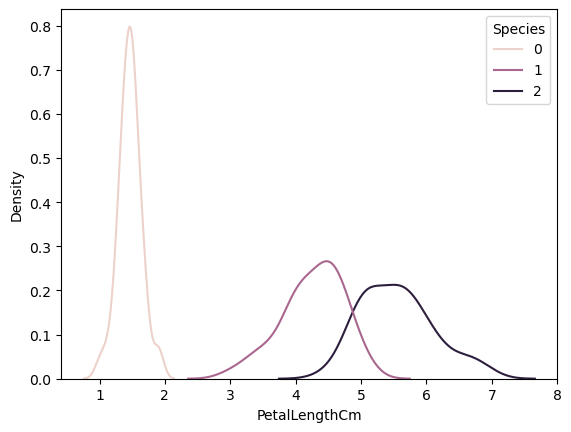

In [34]:
sns.kdeplot(
    data=df,
    x='PetalLengthCm',
    hue='Species'
)

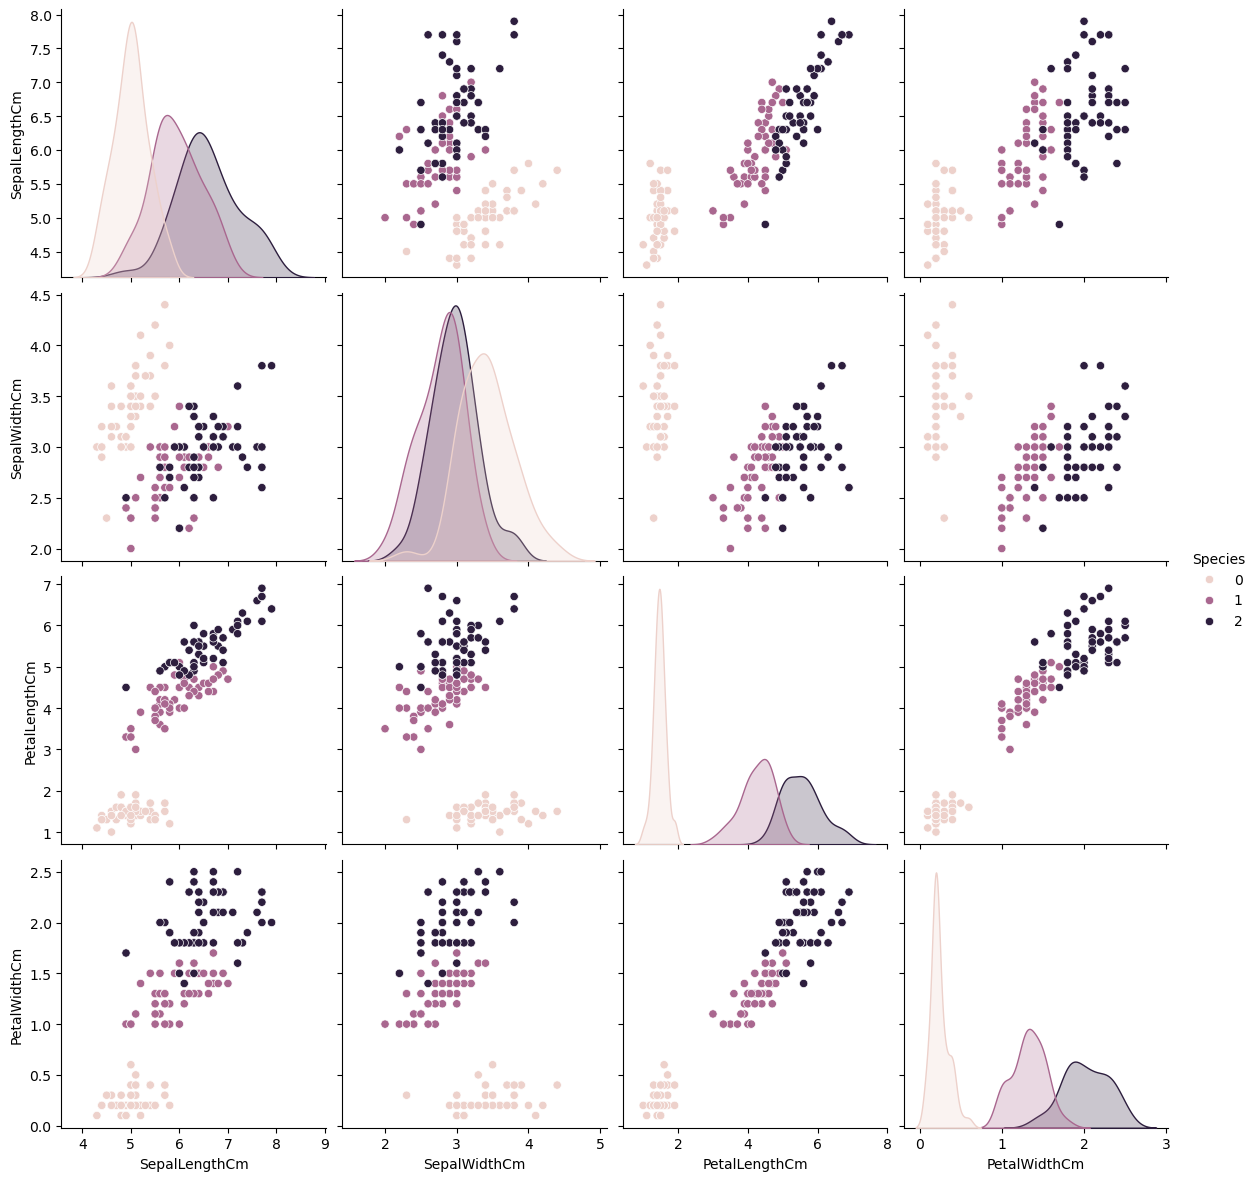

In [35]:
# 'Id' varsa siler, yoksa hata vermeden geçer
sns.pairplot(df.drop("Id", axis=1, errors='ignore'), hue="Species", height=3)

array([[<Axes: title={'center': 'PetalLengthCm'}, xlabel='[Species]'>,
        <Axes: title={'center': 'PetalWidthCm'}, xlabel='[Species]'>],
       [<Axes: title={'center': 'SepalLengthCm'}, xlabel='[Species]'>,
        <Axes: title={'center': 'SepalWidthCm'}, xlabel='[Species]'>]],
      dtype=object)

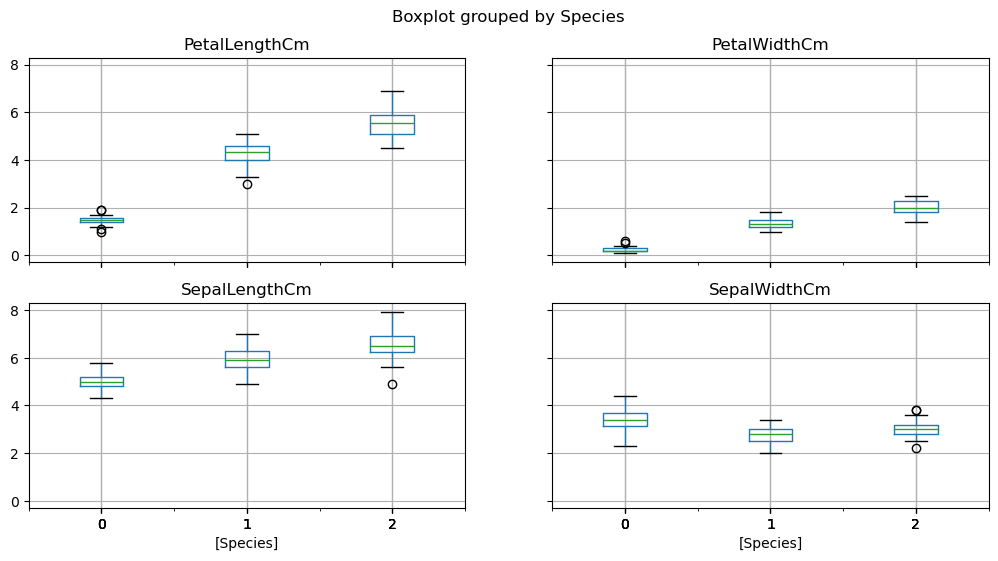

In [36]:
df.drop("Id", axis=1, errors='ignore').boxplot(by="Species", figsize=(12, 6))

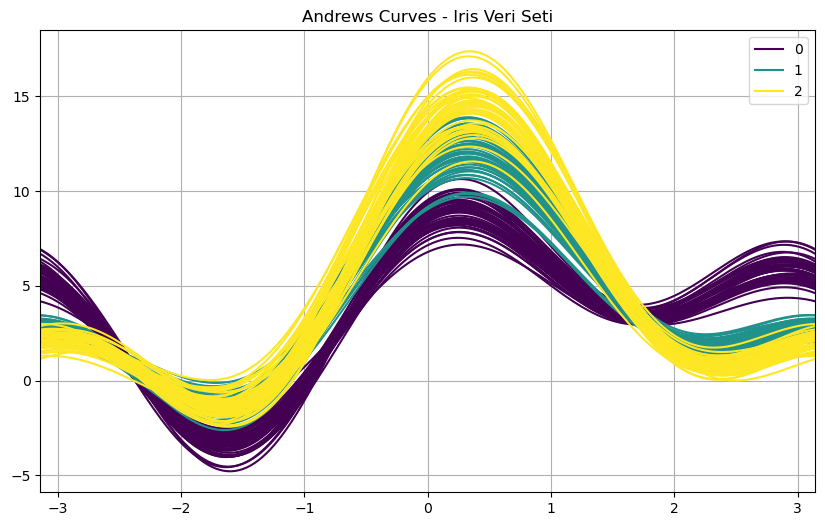

In [37]:
from pandas.plotting import andrews_curves

plt.figure(figsize=(10, 6))
andrews_curves(df.drop("Id", axis=1, errors='ignore'), "Species", colormap='viridis')

plt.title("Andrews Curves - Iris Veri Seti")
plt.show()

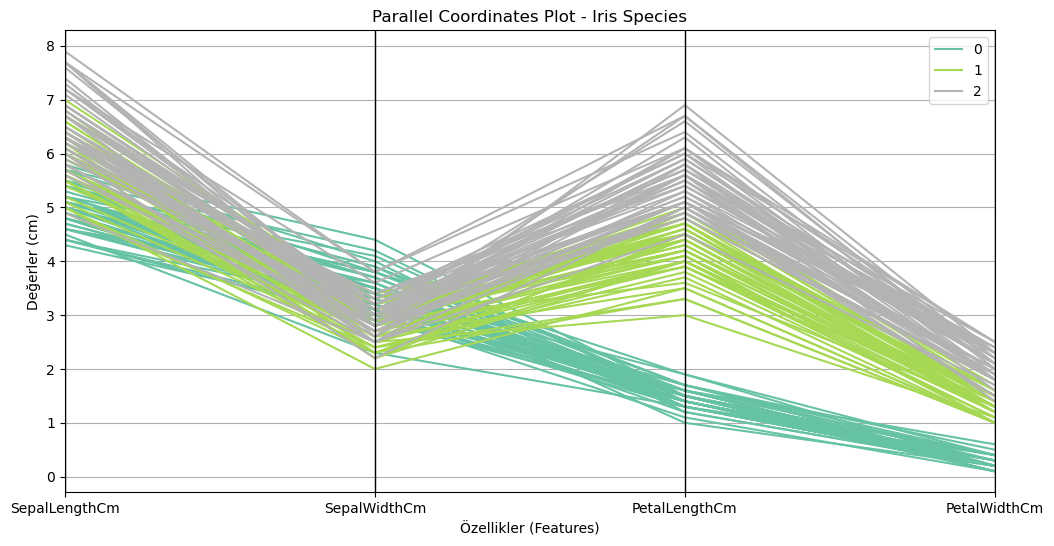

In [38]:
from pandas.plotting import parallel_coordinates

plt.figure(figsize=(12, 6))

parallel_coordinates(df.drop("Id", axis=1, errors='ignore'), "Species", colormap='Set2')

plt.title("Parallel Coordinates Plot - Iris Species")
plt.xlabel("Özellikler (Features)")
plt.ylabel("Değerler (cm)")
plt.show()

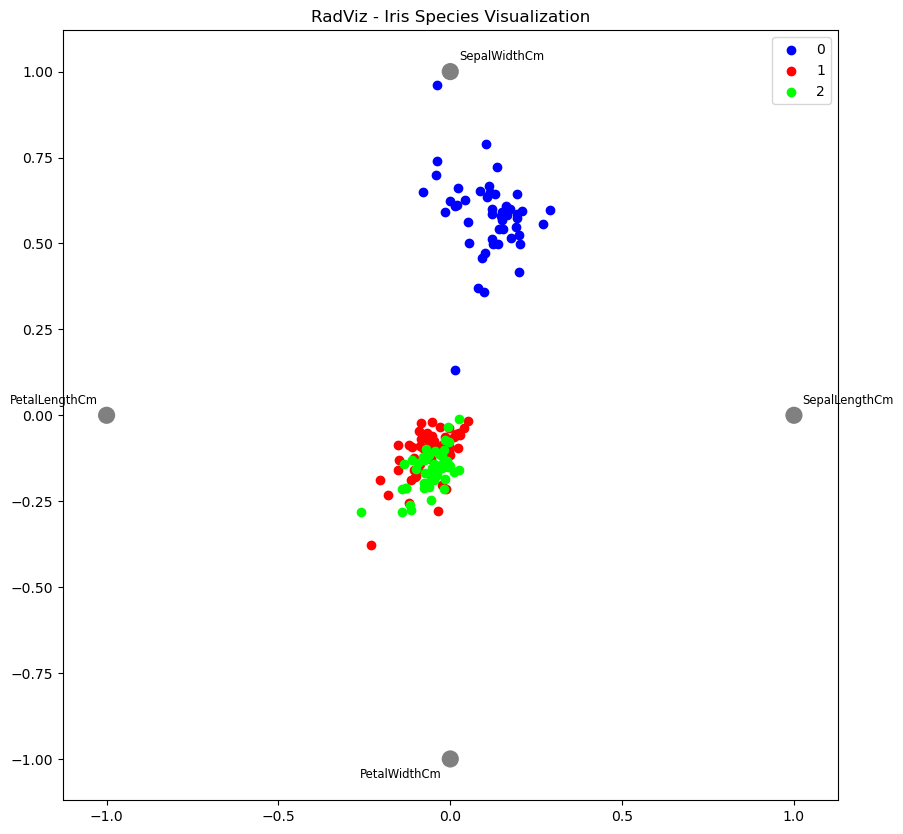

In [39]:
from pandas.plotting import radviz

plt.figure(figsize=(10, 10))

radviz(df.drop("Id", axis=1, errors='ignore'), "Species", colormap='brg')

plt.title("RadViz - Iris Species Visualization")
plt.show()

<Axes: >

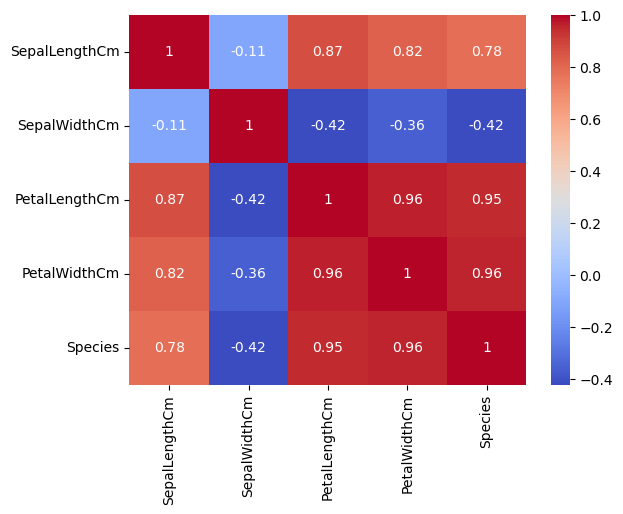

In [40]:
sns.heatmap(df.drop("Id", axis=1, errors="ignore").corr(), annot=True, cmap="coolwarm")

<Axes: xlabel='Species', ylabel='PetalLengthCm'>

C:\Users\furka\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 10.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


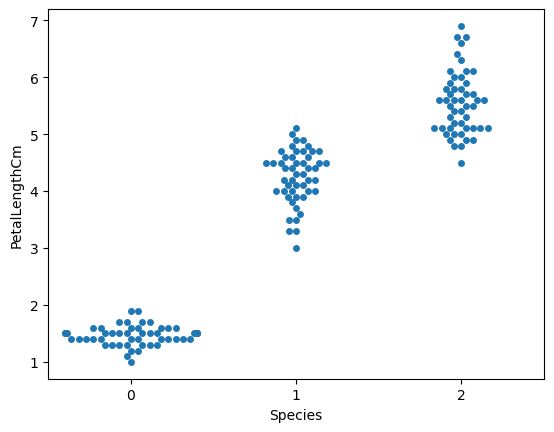

In [41]:
sns.swarmplot(x="Species", y="PetalLengthCm", data=df)

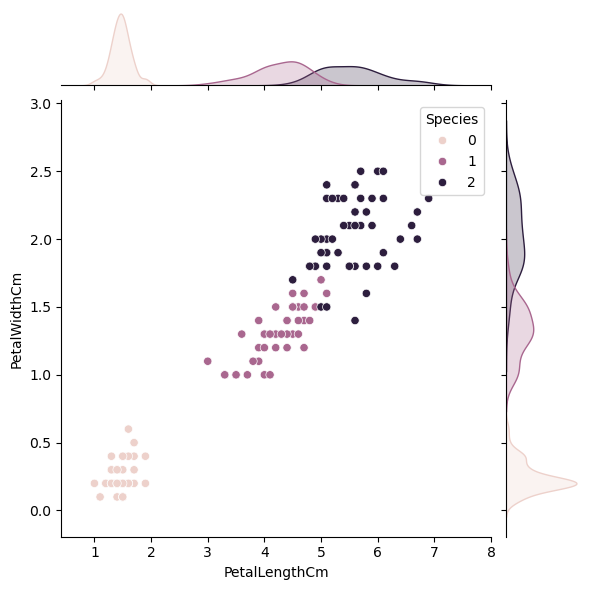

In [42]:
sns.jointplot(x="PetalLengthCm", y="PetalWidthCm", data=df, hue="Species")

<Axes: xlabel='PetalLengthCm', ylabel='PetalWidthCm'>

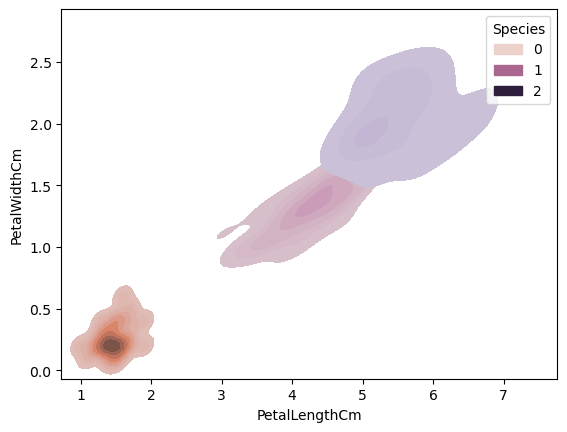

In [43]:
sns.kdeplot(
    data=df,
    x="PetalLengthCm",
    y="PetalWidthCm",
    hue="Species",
    fill=True
)

<Axes: xlabel='Species', ylabel='PetalLengthCm'>

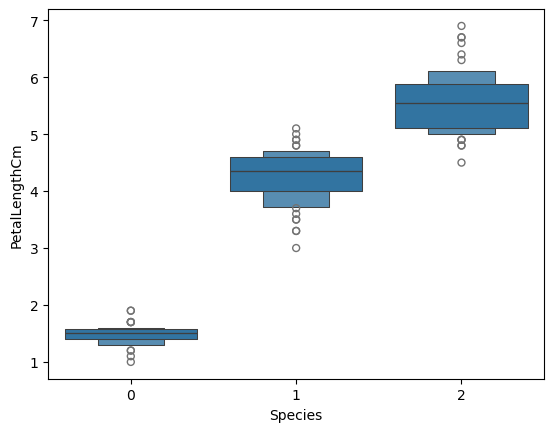

In [44]:
sns.boxenplot(x="Species", y="PetalLengthCm", data=df)

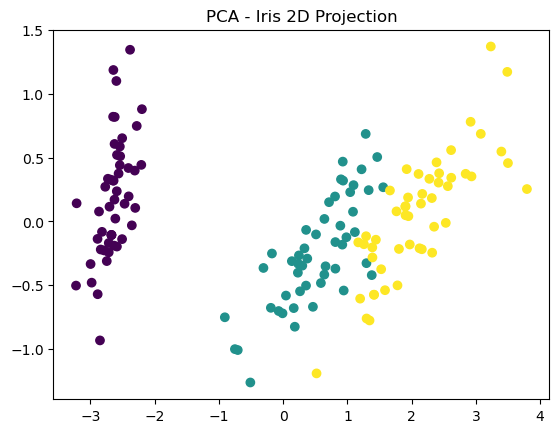

In [45]:
from sklearn.decomposition import PCA

X = df.drop("Species", axis=1)
X = X.drop("Id", axis=1, errors="ignore")

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:,0], X_pca[:,1], c=df["Species"].astype("category").cat.codes)
plt.title("PCA - Iris 2D Projection")
plt.show()

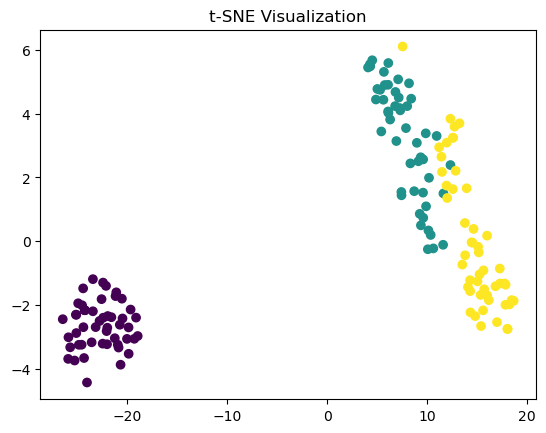

In [46]:
from sklearn.manifold import TSNE

X = df.drop(["Species","Id"], axis=1, errors="ignore")

tsne = TSNE(n_components=2, perplexity=30)
X_tsne = tsne.fit_transform(X)

plt.scatter(X_tsne[:,0], X_tsne[:,1], c=df["Species"].astype("category").cat.codes)
plt.title("t-SNE Visualization")
plt.show()

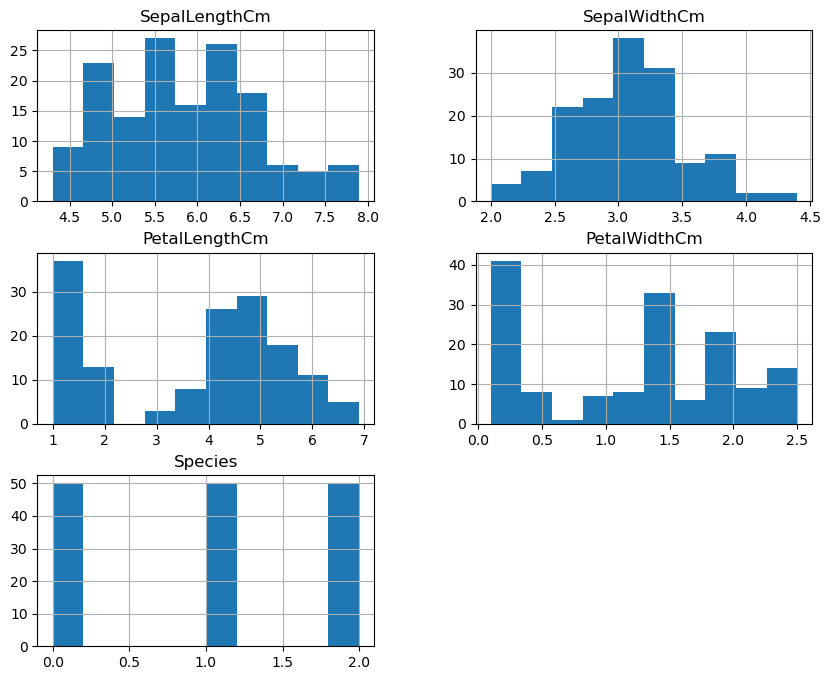

In [47]:
df.drop("Id", axis=1, errors="ignore").hist(figsize=(10,8))
plt.show()

In [53]:
from sklearn.linear_model import LogisticRegression
logistic=LogisticRegression()
logistic.fit(X_train_scaled,y_train)
y_pred=logistic.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[12  0  0]
 [ 0 14  0]
 [ 0  0 12]]
1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



In [58]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

svc_model = SVC(kernel="rbf")

svc_model.fit(X_train_scaled, y_train)

svc_pred = svc_model.predict(X_test_scaled)

print(confusion_matrix(y_test, svc_pred))
print(accuracy_score(y_test, svc_pred))
print(classification_report(y_test, svc_pred))

[[12  0  0]
 [ 0 14  0]
 [ 0  0 12]]
1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38

